In [1]:
!pip install nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
df = pd.read_csv("Twitter_Data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [6]:
df.info()

df['category'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


,count
category,
1.0,72250
0.0,55213
-1.0,35510


In [7]:
df = df.dropna()

In [8]:
df['category'] = df['category'].replace({
    1: 'positive',
    0: 'neutral',
    -1: 'negative'
})

In [9]:
df['clean_text'] = df['clean_text'].str.lower()

In [10]:
stop_words = set(stopwords.words('english'))

df['clean_text'] = df['clean_text'].apply(
    lambda x: ' '.join(word for word in x.split() if word not in stop_words)
)

In [11]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_text'])

y = df['category']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.5759955820089587
              precision    recall  f1-score   support

    negative       0.94      0.12      0.22      7152
     neutral       0.88      0.34      0.49     11067
    positive       0.52      0.98      0.68     14375

    accuracy                           0.58     32594
   macro avg       0.78      0.48      0.46     32594
weighted avg       0.73      0.58      0.51     32594



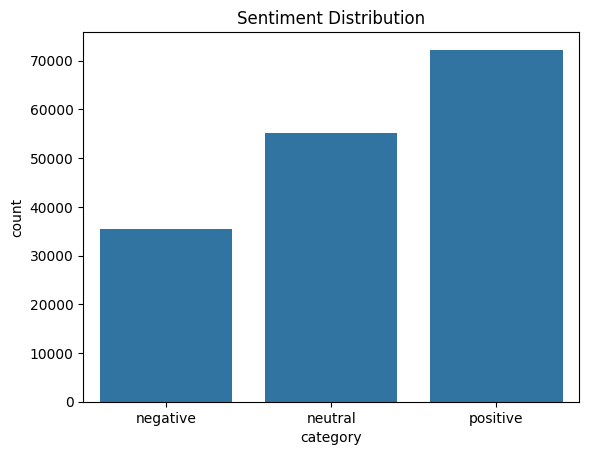

In [16]:
sns.countplot(x='category', data=df)

plt.title("Sentiment Distribution")

plt.show()

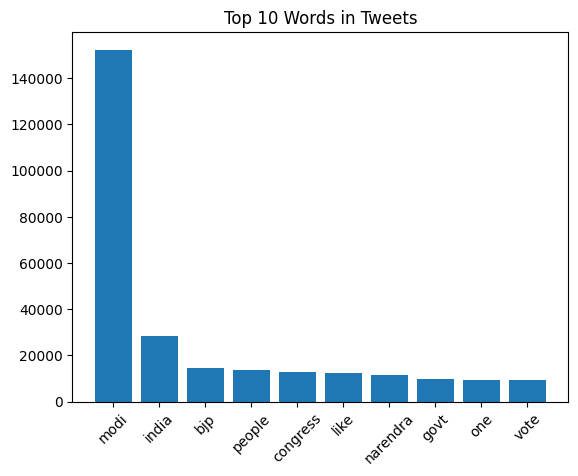

In [17]:
from collections import Counter

words = " ".join(df['clean_text']).split()

common_words = Counter(words).most_common(10)

words, counts = zip(*common_words)

plt.bar(words, counts)

plt.title("Top 10 Words in Tweets")

plt.xticks(rotation=45)

plt.show()

In [18]:
tweet = ["This government decision is amazing"]

tweet_vec = vectorizer.transform(tweet)

prediction = model.predict(tweet_vec)

print("Sentiment:", prediction[0])

Sentiment: positive


In [19]:
import pickle

pickle.dump(model, open("sentiment_model.pkl", "wb"))